In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
!pip install numpy matplotlib seaborn scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [28]:
df=pd.read_csv('/content/drive/MyDrive/python_clean_data.csv')

In [29]:
def desp_stat(col, plt_type):
  col_mean=df[col].mean()
  col_std=df[col].std()
  col_median=df[col].median()
  col_min=df[col].min()
  col_max=df[col].max()
  col_q1=df[col].quantile(0.25)
  col_q3=df[col].quantile(0.75)
  col_iqr=col_q3-col_q1
  print(f"Mean: {col_mean:.2f}")
  print(f"Standard Deviation: {col_std:.2f}")
  print(f"Median: {col_median:.2f}")
  print(f"Minimum: {col_min:.2f}")
  print(f"Maximum: {col_max:.2f}")
  print(f"Q1: {col_q1:.2f}")
  print(f"Q3: {col_q3:.2f}")
  print(f"IQR: {col_iqr:.2f}")
  if plt_type=="hist":
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()
  elif plt_type=="box":
    plt.boxplot(df[col])
    plt.ylabel(col)
    plt.title(f"Boxplot of {col}")
    plt.show()
  else:
    print('No plot is required.')

In [30]:
def dist(col1, col2, num_dist, norm1, norm2):
  if col2==None:
    if norm1==None:
      print(df[col1].value_counts())
    else:
      print(df[col1].value_counts(normalize=True))
  else:
    if num_dist=='Both':
      if norm1==None:
        print(df[col1].value_counts())
      else:
        print(df[col1].value_counts(normalize=True))
      if norm2==None:
        print(df.groupby(col2)[col1].value_counts())
      else:
        print(df.groupby(col2)[col1].value_counts(normalize=True))
    else:
      if norm2==None:
        print(df.groupby(col2)[col1].value_counts())
      else:
        print(df.groupby(col2)[col1].value_counts(normalize=True))

In [31]:
from numpy._core.defchararray import index

def dist_with_mapping(col1, col2, mapping):
  df_mapped=df.groupby(col1)[col2].value_counts(normalize=True)
  df_mapped=df_mapped.rename(index=mapping, level=col1)
  print(df_mapped)

In [32]:
education_level_map={
    1: 'Below College',
2: 'College',
3: 'Bachelor',
4: 'Master',
5: 'Doctor'
}
satisfaction_involvement_map={
1: 'Low',
2: 'Medium',
3: 'High',
4: 'Very High'
}
performance_rating_map={
1: 'Low',
2: 'Good',
3: 'Excellent',
4: 'Outstanding'
}
work_life_balance_map={
1: 'Bad',
2: 'Good',
3: 'Better',
4: 'Best'
}

##employee profile

###age

Mean: 36.92
Standard Deviation: 9.14
Median: 36.00
Minimum: 18.00
Maximum: 60.00
Q1: 30.00
Q3: 43.00
IQR: 13.00


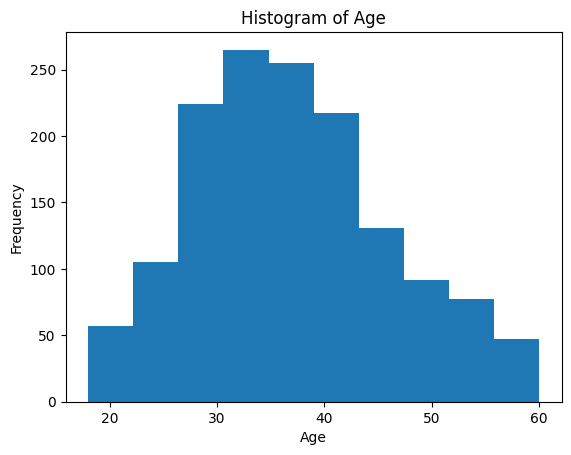

In [33]:
desp_stat('Age',"hist")

###gender

In [35]:
dist('Gender', 'Department', None, None, 'Normalize')

Department              Gender
human resources         male      0.682540
                        female    0.317460
research & development  male      0.605619
                        female    0.394381
sales                   male      0.576233
                        female    0.423767
Name: proportion, dtype: float64


###department sizes

In [37]:
dist('Department', None, None, None , None)

Department
research & development    961
sales                     446
human resources            63
Name: count, dtype: int64


###job role distribution

In [38]:
dist('JobRole', None, None, None, None)

JobRole
sales executive              326
research scientist           292
laboratory technician        259
manufacturing director       145
healthcare representative    131
manager                      102
sales representative          83
research director             80
human resources               52
Name: count, dtype: int64


###education level

In [41]:
dist_with_mapping('Department', 'Education', education_level_map)

Department              Education
human resources         3            0.428571
                        4            0.238095
                        2            0.206349
                        1            0.079365
                        5            0.047619
research & development  3            0.394381
                        4            0.265349
                        2            0.189386
                        1            0.119667
                        5            0.031217
sales                   3            0.372197
                        4            0.286996
                        2            0.195067
                        1            0.112108
                        5            0.033632
Name: proportion, dtype: float64


###years at company

Mean: 7.01
Standard Deviation: 6.13
Median: 5.00
Minimum: 0.00
Maximum: 40.00
Q1: 3.00
Q3: 9.00
IQR: 6.00


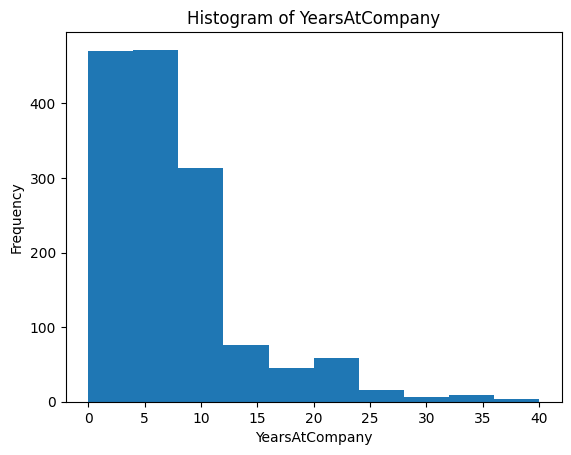

In [42]:
desp_stat('YearsAtCompany',"hist")

In [43]:
print(df.groupby('Department')['YearsAtCompany'].mean())

Department
human resources           7.238095
research & development    6.864724
sales                     7.284753
Name: YearsAtCompany, dtype: float64


## Attrition overview

###overall and by-department attrition rate

In [44]:
dist('Attrition', 'Department', 'Both', 'Normalize', 'Normalize')

Attrition
False    0.838776
True     0.161224
Name: proportion, dtype: float64
Department              Attrition
human resources         False        0.809524
                        True         0.190476
research & development  False        0.861602
                        True         0.138398
sales                   False        0.793722
                        True         0.206278
Name: proportion, dtype: float64


### jobrole attrition

In [45]:
dist('Attrition', 'JobRole', None, None, 'Normalize')

JobRole                    Attrition
healthcare representative  False        0.931298
                           True         0.068702
human resources            False        0.769231
                           True         0.230769
laboratory technician      False        0.760618
                           True         0.239382
manager                    False        0.950980
                           True         0.049020
manufacturing director     False        0.931034
                           True         0.068966
research director          False        0.975000
                           True         0.025000
research scientist         False        0.839041
                           True         0.160959
sales executive            False        0.825153
                           True         0.174847
sales representative       False        0.602410
                           True         0.397590
Name: proportion, dtype: float64


###attrition by gender

In [46]:
dist('Attrition', 'Gender', None, None, 'normalize')

Gender  Attrition
female  False        0.852041
        True         0.147959
male    False        0.829932
        True         0.170068
Name: proportion, dtype: float64


###attrition by marital status

In [47]:
dist('Attrition', 'MaritalStatus', None, None, 'Normalize')

MaritalStatus  Attrition
divorced       False        0.899083
               True         0.100917
married        False        0.875186
               True         0.124814
single         False        0.744681
               True         0.255319
Name: proportion, dtype: float64


###attrition by education

In [48]:
dist_with_mapping('Education', 'Attrition', education_level_map)

Education      Attrition
Below College  False        0.817647
               True         0.182353
College        False        0.843972
               True         0.156028
Bachelor       False        0.826923
               True         0.173077
Master         False        0.854271
               True         0.145729
Doctor         False        0.895833
               True         0.104167
Name: proportion, dtype: float64


###attrition by overtime

In [49]:
dist('Attrition', 'OverTime', None, None, 'Normalize')

OverTime  Attrition
False     False        0.895636
          True         0.104364
True      False        0.694712
          True         0.305288
Name: proportion, dtype: float64


##Salary Overview

In [50]:
original_salary=df['MonthlyIncome']

salary_for_binning = pd.DataFrame({'MonthlyIncome': original_salary})

salary_for_binning['MonthlyIncome'] = pd.cut(
    salary_for_binning['MonthlyIncome'],
    bins=[0, 2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000, 18000, 20000, np.inf], # Use np.inf for the last bin to cover all values >= 30
    labels=['0-2000', '2000-4000', '4000-6000', '6000-8000', '8000-10000', '10000-12000', '12000-14000','14k-16k','16k-18k', '18k-20k', '20k+'],
    right=False

print(salary_for_binning['MonthlyIncome'].value_counts().sort_index())

MonthlyIncome
0-2000          33
2000-4000      509
4000-6000      372
6000-8000      175
8000-10000     100
10000-12000     86
12000-14000     53
14k-16k         16
16k-18k         57
18k-20k         69
20k+             0
Name: count, dtype: int64


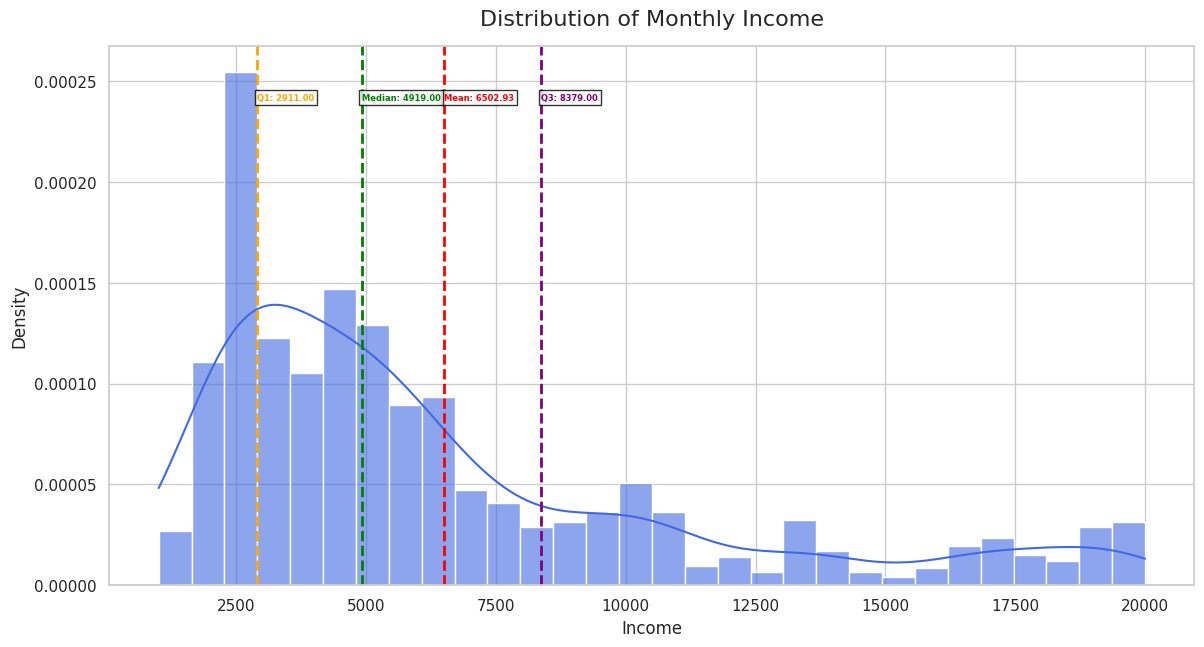

In [51]:
from kagglehub.packages import EXPORTED_PACKAGE_ASSETS_DIR
from matplotlib import text
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df_sal = pd.DataFrame({'MonthlyIncome': original_salary})

mean_value = df_sal['MonthlyIncome'].mean()
median_value = df_sal['MonthlyIncome'].median()
q1_value = df_sal['MonthlyIncome'].quantile(0.25)
q3_value = df_sal['MonthlyIncome'].quantile(0.75)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

ax=sns.histplot(
    data=df_sal,
    x="MonthlyIncome",
    kde=True,
    stat="density",
    bins=30,
    color="royalblue",
    alpha=0.6,
    edgecolor="white",
metrics={
    "Mean": {"value": mean_value, "color": "red"},
    "Median": {"value": median_value, "color": "green"},
    "Q1": {"value": q1_value, "color": "orange"},
    "Q3": {"value": q3_value, "color": "purple"},
}
y_max=ax.get_ylim()[1]
text_y_position=y_max*0.9

for metric_name, metric_values in metrics.items():
  plt.axvline(
      metric_values["value"],
      color=metric_values["color"],
      linestyle="--",
      linewidth=2,
      label=f"{metric_name}: {metric_values['value']:.2f}"
  )
  plt.text(
      metric_values["value"],
      text_y_position,
      f"{metric_name}: {metric_values['value']:.2f}",
      color=metric_values["color"],
      fontsize=6,
      fontweight="bold",
      bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", pad=2))

plt.title("Distribution of Monthly Income", fontsize=16, pad=15)
plt.xlabel("Income", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.show()

In [52]:
print(df.groupby('Department')['MonthlyIncome'].mean())

Department
human resources           6654.507937
research & development    6281.252862
sales                     6959.172646
Name: MonthlyIncome, dtype: float64


In [53]:
print(df.groupby('JobLevel')['MonthlyIncome'].mean())

JobLevel
1     2786.915285
2     5502.277154
3     9817.252294
4    15503.783019
5    19191.826087
Name: MonthlyIncome, dtype: float64


##Work-Life Balance Analysis

In [54]:
dist_with_mapping('WorkLifeBalance', 'Attrition', work_life_balance_map)

WorkLifeBalance  Attrition
Bad              False        0.687500
                 True         0.312500
Good             False        0.831395
                 True         0.168605
Better           False        0.857783
                 True         0.142217
Best             False        0.823529
                 True         0.176471
Name: proportion, dtype: float64


###business travel

In [55]:
dist('Attrition', 'BusinessTravel', None, None, 'Normalize')

BusinessTravel     Attrition
non-travel         False        0.920000
                   True         0.080000
travel_frequently  False        0.750903
                   True         0.249097
travel_rarely      False        0.850431
                   True         0.149569
Name: proportion, dtype: float64


###environment satisfaction

In [56]:
dist_with_mapping('EnvironmentSatisfaction', 'Attrition', satisfaction_involvement_map)

EnvironmentSatisfaction  Attrition
Low                      False        0.746479
                         True         0.253521
Medium                   False        0.850174
                         True         0.149826
High                     False        0.863135
                         True         0.136865
Very High                False        0.865471
                         True         0.134529
Name: proportion, dtype: float64


In [57]:
dist_with_mapping('EnvironmentSatisfaction', 'Attrition', satisfaction_involvement_map)

EnvironmentSatisfaction  Attrition
Low                      False        0.746479
                         True         0.253521
Medium                   False        0.850174
                         True         0.149826
High                     False        0.863135
                         True         0.136865
Very High                False        0.865471
                         True         0.134529
Name: proportion, dtype: float64


###relationship satisfaction

In [58]:
dist_with_mapping('RelationshipSatisfaction', 'Attrition', satisfaction_involvement_map)

RelationshipSatisfaction  Attrition
Low                       False        0.793478
                          True         0.206522
Medium                    False        0.851485
                          True         0.148515
High                      False        0.845316
                          True         0.154684
Very High                 False        0.851852
                          True         0.148148
Name: proportion, dtype: float64


###job satisfaction

In [59]:
dist_with_mapping('JobSatisfaction', 'Attrition', satisfaction_involvement_map)

JobSatisfaction  Attrition
Low              False        0.771626
                 True         0.228374
Medium           False        0.835714
                 True         0.164286
High             False        0.834842
                 True         0.165158
Very High        False        0.886710
                 True         0.113290
Name: proportion, dtype: float64


###job involvement

In [60]:
dist_with_mapping('JobInvolvement', 'Attrition', satisfaction_involvement_map)

JobInvolvement  Attrition
Low             False        0.662651
                True         0.337349
Medium          False        0.810667
                True         0.189333
High            False        0.855991
                True         0.144009
Very High       False        0.909722
                True         0.090278
Name: proportion, dtype: float64


##Career Growth analysis

Mean: 7.01
Standard Deviation: 6.13
Median: 5.00
Minimum: 0.00
Maximum: 40.00
Q1: 3.00
Q3: 9.00
IQR: 6.00


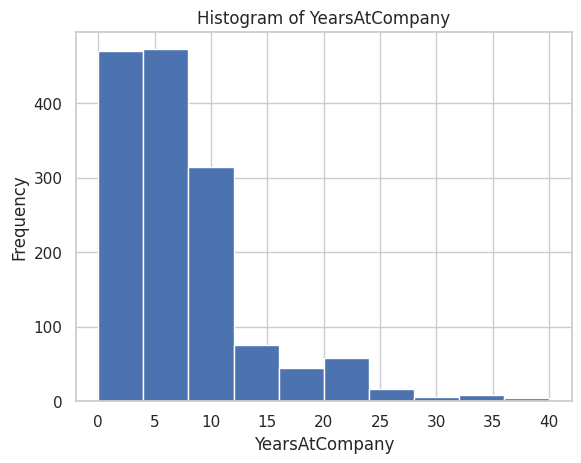

In [61]:
desp_stat('YearsAtCompany', 'hist')

Mean: 4.23
Standard Deviation: 3.62
Median: 3.00
Minimum: 0.00
Maximum: 18.00
Q1: 2.00
Q3: 7.00
IQR: 5.00


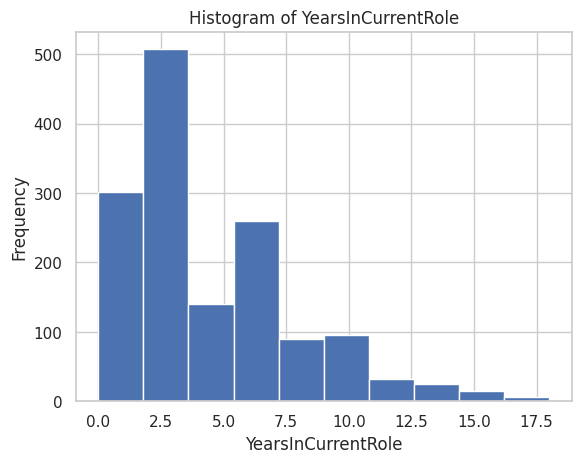

In [62]:
desp_stat('YearsInCurrentRole', 'hist')

Mean: 2.19
Standard Deviation: 3.22
Median: 1.00
Minimum: 0.00
Maximum: 15.00
Q1: 0.00
Q3: 3.00
IQR: 3.00


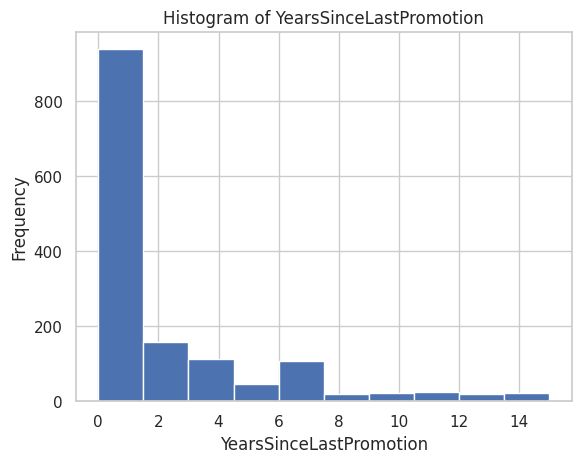

In [63]:
desp_stat('YearsSinceLastPromotion', 'hist')

Mean: 2.80
Standard Deviation: 1.29
Median: 3.00
Minimum: 0.00
Maximum: 6.00
Q1: 2.00
Q3: 3.00
IQR: 1.00


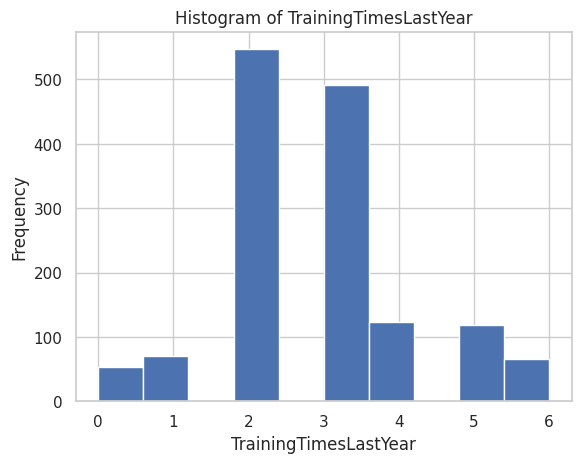

In [64]:
desp_stat('TrainingTimesLastYear', 'hist')